In [1]:
import pandas as pd

file_path = 'metadata.csv' 

# low_memory=False --> złożony plik
df = pd.read_csv(file_path, low_memory=False)


### podstawowa analiza
print("Kształt danych (wiersze, kolumny):")
print(df.shape)
print("-" * 30)

print("Pierwsze 5 wierszy:")
print(df.head())
print("-" * 30)

print("Info o typach danych:")
df.info()
print("-" * 30)


print("Kolumny:")
print(df.columns)
print("-" * 30)

print("Liczba brakujących wartości w kolumnach:")
print(df.isnull().sum())

Kształt danych (wiersze, kolumny):
(1056660, 19)
------------------------------
Pierwsze 5 wierszy:
   cord_uid                                       sha source_x  \
0  ug7v899j  d1aafb70c066a2068b02786f8929fd9c900897fb      PMC   
1  02tnwd4m  6b0567729c2143a66d737eb0a2f63f2dce2e5a7d      PMC   
2  ejv2xln0  06ced00a5fc04215949aa72528f2eeaae1d58927      PMC   
3  2b73a28n  348055649b6b8cf2b9a376498df9bf41f7123605      PMC   
4  9785vg6d  5f48792a5fa08bed9f56016f4981ae2ca6031b32      PMC   

                                               title                    doi  \
0  Clinical features of culture-proven Mycoplasma...  10.1186/1471-2334-1-6   
1  Nitric oxide: a pro-inflammatory mediator in l...           10.1186/rr14   
2    Surfactant protein-D and pulmonary host defense           10.1186/rr19   
3               Role of endothelin-1 in lung disease           10.1186/rr44   
4  Gene expression in epithelial cells in respons...           10.1186/rr61   

      pmcid pubmed_id licens

In [2]:
print(f"Rozmiar danych przed czyszczeniem: {df.shape}")

### tylko potrzebne kolumny: title i abstract
### .copy()  -->  nowa niezależna ramka danych
df_clean = df[['title', 'abstract']].copy()

### usunięcie wierszy, w których brak jednoczesnie tytułu i abstraktu
### wiersz zostanie usunięty tylko jeśli wszystkie wartości w podanych kolumnach subset są puste (NaN)
df_clean.dropna(subset=['title', 'abstract'], how='all', inplace=True)

print(f"Rozmiar po usunięciu wierszy bez tytułu i abstraktu: {df_clean.shape}")

### usunięcie duplikatów na podstawie kolumny title
df_clean.drop_duplicates(subset=['title'], inplace=True)

print(f"Rozmiar po usunięciu duplikatów: {df_clean.shape}")


print("\nLiczba brakujących wartości po czyszczeniu:")
print(df_clean.isnull().sum())


print("\nPróbka danych po czyszczeniu:")
print(df_clean.head())

Rozmiar danych przed czyszczeniem: (1056660, 19)
Rozmiar po usunięciu wierszy bez tytułu i abstraktu: (1056268, 2)
Rozmiar po usunięciu duplikatów: (850367, 2)

Liczba brakujących wartości po czyszczeniu:
title            1
abstract    176878
dtype: int64

Próbka danych po czyszczeniu:
                                               title  \
0  Clinical features of culture-proven Mycoplasma...   
1  Nitric oxide: a pro-inflammatory mediator in l...   
2    Surfactant protein-D and pulmonary host defense   
3               Role of endothelin-1 in lung disease   
4  Gene expression in epithelial cells in respons...   

                                            abstract  
0  OBJECTIVE: This retrospective chart review des...  
1  Inflammatory diseases of the respiratory tract...  
2  Surfactant protein-D (SP-D) participates in th...  
3  Endothelin-1 (ET-1) is a 21 amino acid peptide...  
4  Respiratory syncytial virus (RSV) and pneumoni...  


In [3]:
import re

### zastąpienie wartości NaN pustym tekstem ''
df_clean.fillna('', inplace=True)

### nowa połączona kolumna 'text' ### spacja ' ' pomiędzy aby tytuł nie skleił się z abstraktem
df_clean['text'] = df_clean['title'] + ' ' + df_clean['abstract']

### funkcja do czyszczenia tekstu
def preprocess_text(text):
    text = text.lower()  ## zamiana na małe litery
    text = re.sub(r'[^\w\s]', '', text)  ## usunięcie interpunkcji
    text = re.sub(r'\d+', '', text)  ## usunięcie cyfr
    text = re.sub(r'\s+', ' ', text).strip() ## usunięcie nadmiarowych białych znaków
    return text


print("Czyszczenie tekstu...")
df_clean['text_clean'] = df_clean['text'].apply(preprocess_text)
print("Czyszczenie zakończone.")

### 5 wierszy z kolumną oryginalną i wyczyszczoną dla porównania
print("\nPorównanie tekstu oryginalnego i wyczyszczonego:")
print(df_clean[['text', 'text_clean']].head())

Czyszczenie tekstu...
Czyszczenie zakończone.

Porównanie tekstu oryginalnego i wyczyszczonego:
                                                text  \
0  Clinical features of culture-proven Mycoplasma...   
1  Nitric oxide: a pro-inflammatory mediator in l...   
2  Surfactant protein-D and pulmonary host defens...   
3  Role of endothelin-1 in lung disease Endotheli...   
4  Gene expression in epithelial cells in respons...   

                                          text_clean  
0  clinical features of cultureproven mycoplasma ...  
1  nitric oxide a proinflammatory mediator in lun...  
2  surfactant proteind and pulmonary host defense...  
3  role of endothelin in lung disease endothelin ...  
4  gene expression in epithelial cells in respons...  


In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
import time

### wektoryzacja TF-IDF 
### stop_words='english' --> usuwa angielskie stop_words
## min_df=5 - ignoruje słowa, które wystąpiły w mniej niż 5 dokumentach (prawdopodobnie literówki)
## max_df=0.95 - ignoruj słowa, które wystąpiły w więcej niż 95% dokumentów (zbyt ogólne)
vectorizer = TfidfVectorizer(stop_words='english', min_df=5, max_df=0.95)

### mierzenie czasu
start_time = time.time()

### dopasowanie wektoryzatora do danych i transformacja tekstów na macierz TF-IDF
print("Rozpoczynam wektoryzację TF-IDF...")
tfidf_matrix = vectorizer.fit_transform(df_clean['text_clean'])
print("Wektoryzacja zakończona.")


end_time = time.time()
elapsed_time = end_time - start_time
print(f"Czas wykonania: {elapsed_time / 60:.2f} minut")


print("\nKształt macierzy TF-IDF (dokumenty, unikalne słowa):")
print(tfidf_matrix.shape)

Rozpoczynam wektoryzację TF-IDF...
Wektoryzacja zakończona.
Czas wykonania: 0.66 minut

Kształt macierzy TF-IDF (dokumenty, unikalne słowa):
(850367, 167120)


In [10]:
import joblib

### zapisanie macierzy TF-IDF
joblib.dump(tfidf_matrix, 'tfidf_matrix.joblib')
print("Macierz zapisana w pliku 'tfidf_matrix.joblib'")

### zapisanie wektoryzatora
joblib.dump(vectorizer, 'vectorizer.joblib')
print("Wektoryzator zapisany w pliku 'vectorizer.joblib'")

Macierz zapisana w pliku 'tfidf_matrix.joblib'
Wektoryzator zapisany w pliku 'vectorizer.joblib'


In [12]:
from sklearn.cluster import MiniBatchKMeans
import numpy as np

### klastrowanie z MiniBatchKMeans
### praca na macierzy TF-IDF nie na oryginalnym DataFrame

### wstępna liczba klastrów (tematów)
num_clusters = 10

## batch_size=1024 to standardowa wartość
kmeans = MiniBatchKMeans(n_clusters=num_clusters, 
                         random_state=42, 
                         batch_size=1024, 
                         n_init='auto')

### trenowanie modelu na pełnej macierzy TF-IDF
print("Trenowanie modelu klastrującego...")
kmeans.fit(tfidf_matrix)
print("Trenowanie zakończone.")


print("\nNajważniejsze słowa kluczowe dla każdego z klastrów:")

terms = vectorizer.get_feature_names_out() 
## pobranie centroidów klastrów
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]

for i in range(num_clusters):
    print(f"Klaster {i}: ", end="")
    for ind in order_centroids[i, :10]: ### wyświetl 10 najlepszych słów
        print(f"{terms[ind]} ", end="")
    print()

Trenowanie modelu klastrującego...
Trenowanie zakończone.

Najważniejsze słowa kluczowe dla każdego z klastrów:
Klaster 0: cells virus protein cell viral sarscov viruses expression human proteins 
Klaster 1: care health covid pandemic healthcare patients services public workers medical 
Klaster 2: covid pandemic la case patients treatment disease study clinical patient 
Klaster 3: sarscov respiratory infection covid coronavirus syndrome acute severe disease patients 
Klaster 4: vaccination covid vaccine sarscov vaccines vaccinated patients influenza mrna dose 
Klaster 5: vaccine vaccines covid vaccination sarscov mrna dose hesitancy bntb development 
Klaster 6: dental oral covid dentists health patients care pandemic dentistry practice 
Klaster 7: patients covid mortality disease clinical study risk ci treatment severe 
Klaster 8: covid pandemic data model social research health study using analysis 
Klaster 9: students mental covid learning pandemic health anxiety online education stu

In [14]:
### analiza i eksploracja klastrów

### przypisanie etykiet klastrów do data frame
#### model po treningu przechowuje przypisania w atrybucie .labels_
df_clean['cluster'] = kmeans.labels_

### liczebność każdego klastra
print("Liczebność klastrów:")
print(df_clean['cluster'].value_counts().sort_index())

### kilka przykładowych tytułów z wybranego klastra -> specyficzny klaster nr 6 (stomatologia)
print("\nPrzykładowe tytuły z Klastra 6 (Stomatologia)")

# 10 losowych tytułów z klastra 6
sample_titles = df_clean[df_clean['cluster'] == 6]['title'].sample(10, random_state=1).values

for title in sample_titles:
    print(f"- {title}")


Liczebność klastrów:
cluster
0     81546
1     62778
2    295085
3     70047
4     11696
5     17724
6      4081
7     92502
8    164118
9     50790
Name: count, dtype: int64

Przykładowe tytuły z Klastra 6 (Stomatologia)
- SARS-CoV-2: A Professional and social gamechanger - Medical and dental aspects
- Awareness of coronavirus among dental students - A questionnaire-based study
- Each for Equal: Gender Inequity in Dentistry in Australia.
- Hospitalization for Oral Health-Related Conditions of the Australian Ageing Population: Two Decades of Analysis
- Comparison of oral health behaviour between dental and non-dental undergraduates in a university in southwestern China--exploring the future priority for oral health education
- Oral Health Policy and Improvement Strategies in Oklahoma
- Dental Treatments During the COVID-19 Pandemic in Three Hospitals in Jordan: A Retrospective Study
- A Review of Aerosol Generation Mitigation in International Dental Guidance
- Evaluation of knowledge a

In [16]:
import joblib

joblib.dump(kmeans, 'kmeans_model.joblib')
print("Model zapisany w pliku 'kmeans_model.joblib'")


joblib.dump(df_clean, 'df_clean_with_ten_clusters.joblib')
print("DataFrame zapisany w pliku 'df_clean_with_ten_clusters.joblib'")

Model zapisany w pliku 'kmeans_model.joblib'
DataFrame zapisany w pliku 'df_clean_with_ten_clusters.joblib'


In [1]:
import pandas as pd
import joblib

### wczytywanie obiektów
vectorizer = joblib.load('vectorizer.joblib')
tfidf_matrix = joblib.load('tfidf_matrix.joblib')
kmeans_model = joblib.load('kmeans_model.joblib')
df_clean = joblib.load('df_clean_with_ten_clusters.joblib')

print("Obiekty wczytane.")

Obiekty wczytane.


Tworzenie losowej próbki 50000 dokumentów do wizualizacji...
Redukcja wymiarowości za pomocą t-SNE...


O:\Projects\fashion_mnist\pyth311env\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Redukcja wymiarowości zakończona.


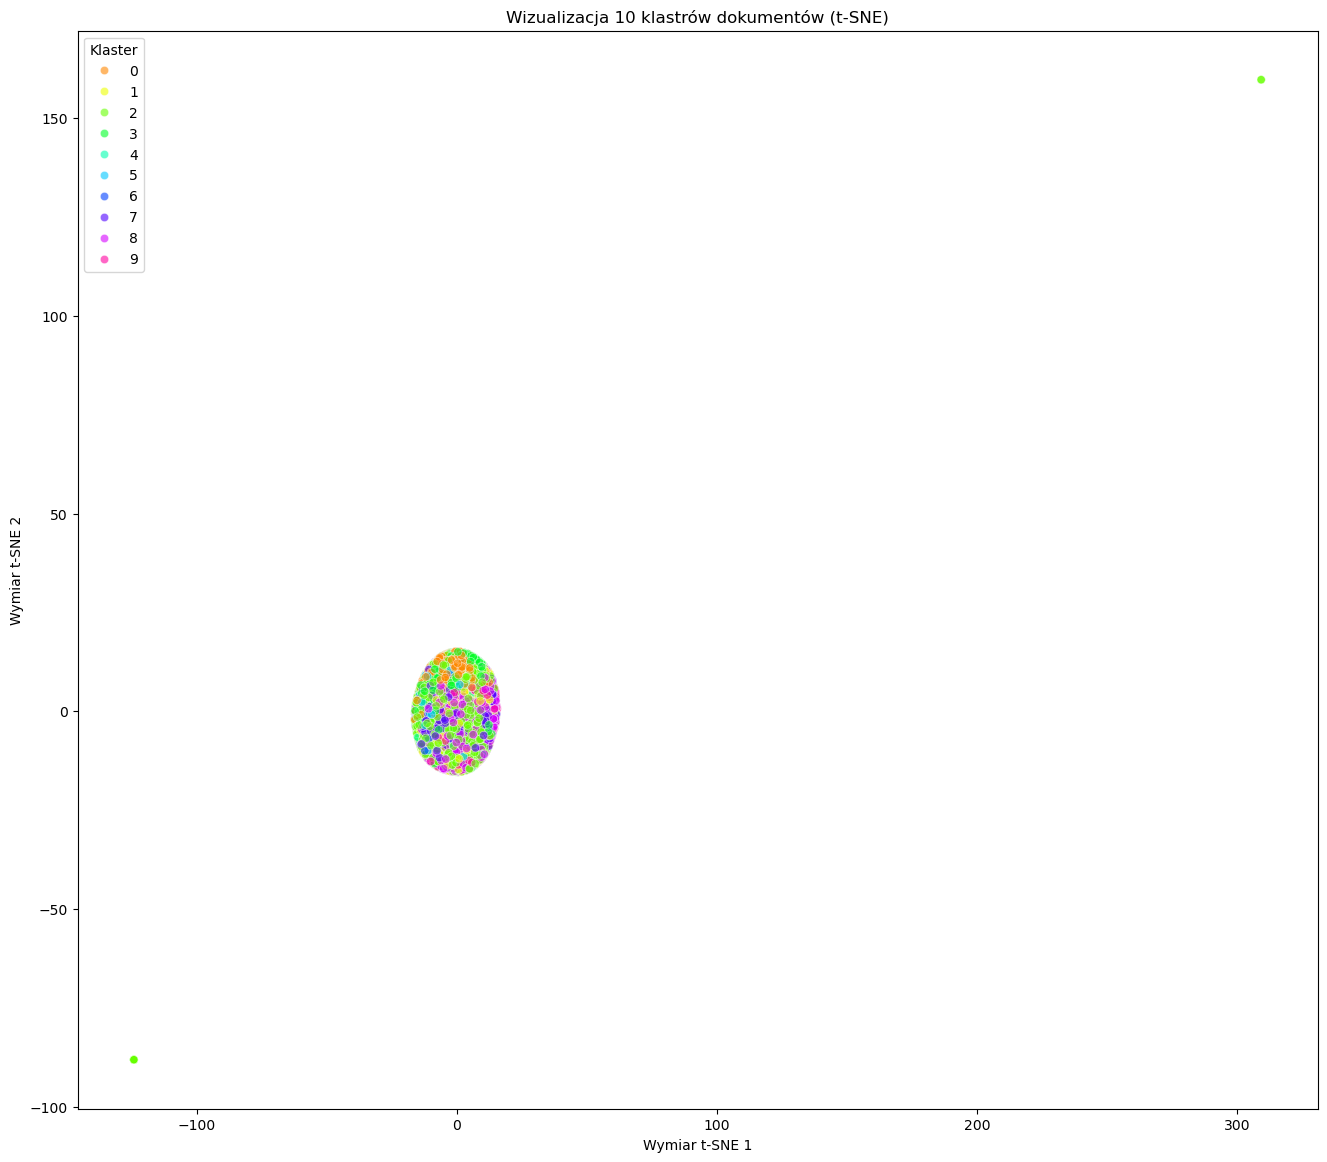

In [3]:
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

### wizualizacja klastrów ###

n_samples = 50000 ## losowa próbka
if tfidf_matrix.shape[0] > n_samples:
    print(f"Tworzenie losowej próbki {n_samples} dokumentów do wizualizacji...")
    ### losowe, unikalne indeksy
    random_indices = np.random.choice(tfidf_matrix.shape[0], size=n_samples, replace=False)
    
    ### wybiera wiersze z macierzy i etykiety z DataFrame
    tfidf_sample = tfidf_matrix[random_indices]
    labels_sample = df_clean['cluster'].iloc[random_indices]
else:
    print("Zbiór danych jest wystarczająco mały, używam całości.")
    tfidf_sample = tfidf_matrix
    labels_sample = df_clean['cluster']


##### t-SNE
### n_components=2 -> redukcja do 2 wymiarów (X, Y)
### perplexity=30 -> standardowa wartość dla zbiorów
print("Redukcja wymiarowości za pomocą t-SNE...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=300, n_jobs=-1)
tsne_results = tsne.fit_transform(tfidf_sample.toarray()) ### .toarray() jest ważne dla t-SNE
print("Redukcja wymiarowości zakończona.")


### dane do rysowania wykresu
tsne_df = pd.DataFrame({
    'x': tsne_results[:, 0],
    'y': tsne_results[:, 1],
    'cluster': labels_sample
})

### plot figure
plt.figure(figsize=(16, 14))
sns.scatterplot(
    x='x', y='y',
    hue='cluster',
    palette=sns.color_palette("hsv", n_colors=10), ## paleta 10 kolorów
    data=tsne_df,
    legend="full",
    alpha=0.6
)
plt.title('Wizualizacja 10 klastrów dokumentów (t-SNE)')
plt.xlabel('Wymiar t-SNE 1')
plt.ylabel('Wymiar t-SNE 2')
plt.legend(title='Klaster')
plt.show()

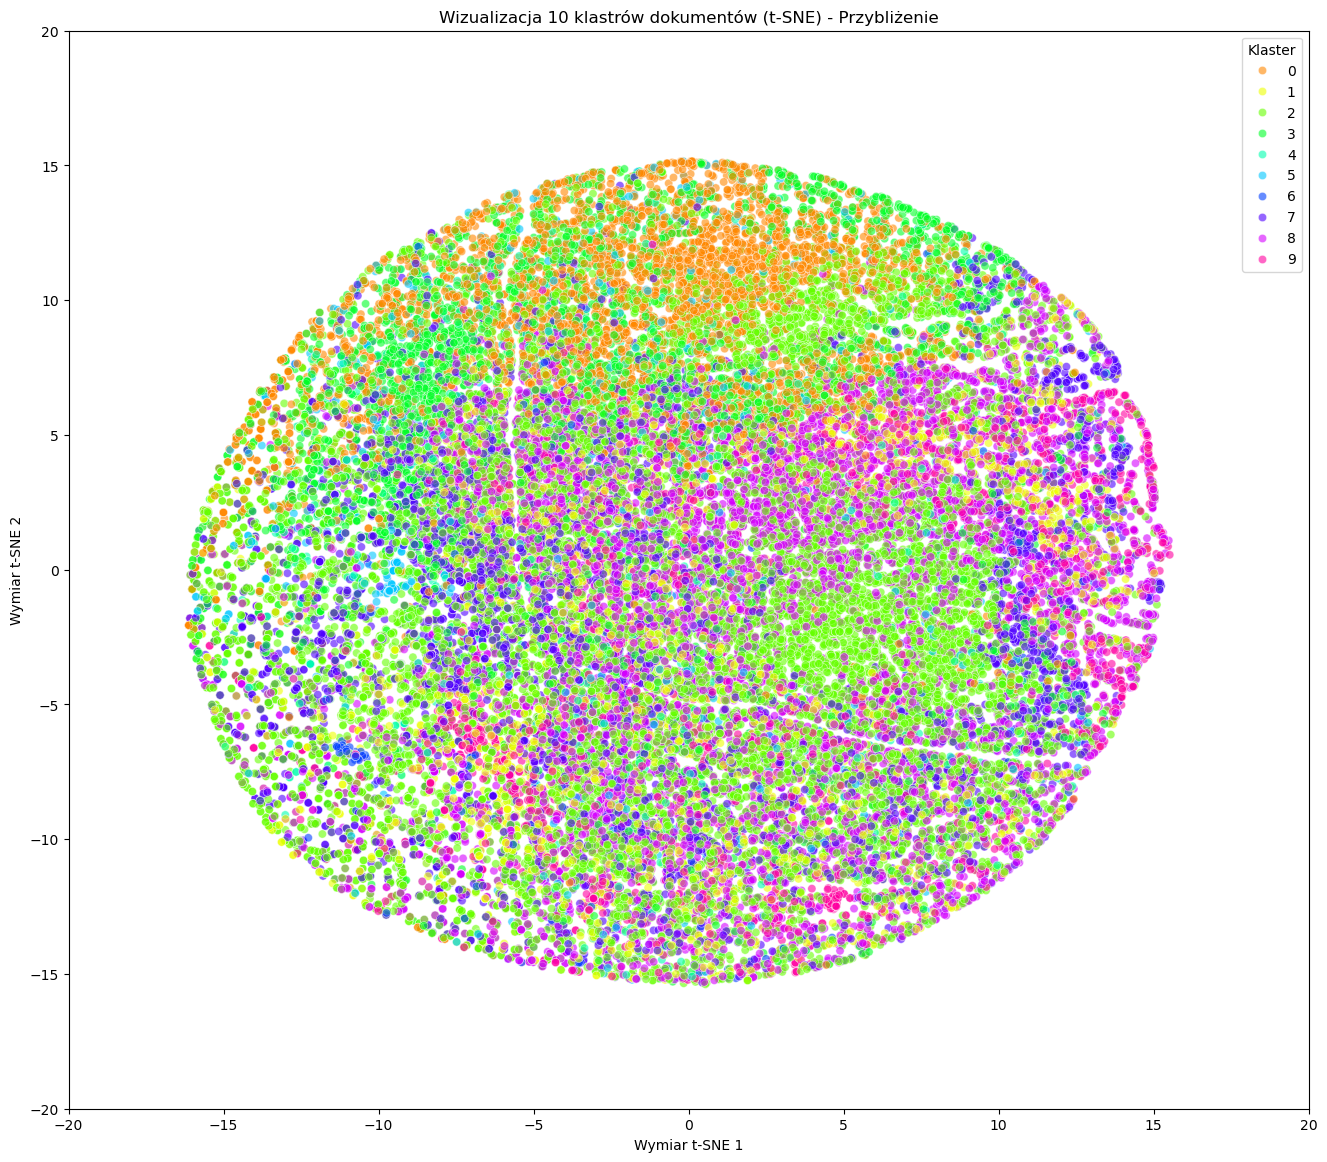

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

### plot figure - zooming on data cluster
plt.figure(figsize=(16, 14))
sns.scatterplot(
    x='x', y='y',
    hue='cluster',
    palette=sns.color_palette("hsv", n_colors=10),
    data=tsne_df,
    legend="full",
    alpha=0.6
)

#### limity dla osi X i Y
plt.xlim(-20, 20)
plt.ylim(-20, 20)

plt.title('Wizualizacja 10 klastrów dokumentów (t-SNE) - Przybliżenie')
plt.xlabel('Wymiar t-SNE 1')
plt.ylabel('Wymiar t-SNE 2')
plt.legend(title='Klaster')
plt.show()

In [9]:
import joblib

joblib.dump(tsne_df, 'tsne_df_10_clusters.joblib')
print("DataFrame z wynikami t-SNE (10 klastrów) został zapisany.")

DataFrame z wynikami t-SNE (10 klastrów) został zapisany.


Podsumowanie modelu z 10 klastrami

In [13]:
### interpretacje tematów dla każdego klastra
topic_names = {
    0: "Wirusologia / Biologia molekularna",
    1: "System opieki zdrowotnej",
    2: "Badania kliniczne / Opisy przypadków",
    3: "Patologia choroby (SARS-CoV-2)",
    4: "Szczepienia (Ogólne)",
    5: "Szczepionki (Rozwój / Wahania)",
    6: "Stomatologia",
    7: "Wyniki kliniczne / Ryzyko",
    8: "Modelowanie / Analiza danych",
    9: "Edukacja / Zdrowie psychiczne"
}


print("="*30)
print("PODSUMOWANIE WYNIKÓW KLASTROWANIA (k=10)")
print("="*30)


terms = vectorizer.get_feature_names_out() 
order_centroids = kmeans_model.cluster_centers_.argsort()[:, ::-1]
cluster_counts = df_clean['cluster'].value_counts()

for i in range(10):
    #### top 5 słów
    top_words = [terms[ind] for ind in order_centroids[i, :5]]
    
    print(f"\nKlaster {i}: {topic_names.get(i, 'Brak nazwy')}")
    print(f"    Liczba dokumentów: {cluster_counts[i]}")
    print(f"    Słowa kluczowe: {', '.join(top_words)}")

PODSUMOWANIE WYNIKÓW KLASTROWANIA (k=10)

Klaster 0: Wirusologia / Biologia molekularna
    Liczba dokumentów: 81546
    Słowa kluczowe: cells, virus, protein, cell, viral

Klaster 1: System opieki zdrowotnej
    Liczba dokumentów: 62778
    Słowa kluczowe: care, health, covid, pandemic, healthcare

Klaster 2: Badania kliniczne / Opisy przypadków
    Liczba dokumentów: 295085
    Słowa kluczowe: covid, pandemic, la, case, patients

Klaster 3: Patologia choroby (SARS-CoV-2)
    Liczba dokumentów: 70047
    Słowa kluczowe: sarscov, respiratory, infection, covid, coronavirus

Klaster 4: Szczepienia (Ogólne)
    Liczba dokumentów: 11696
    Słowa kluczowe: vaccination, covid, vaccine, sarscov, vaccines

Klaster 5: Szczepionki (Rozwój / Wahania)
    Liczba dokumentów: 17724
    Słowa kluczowe: vaccine, vaccines, covid, vaccination, sarscov

Klaster 6: Stomatologia
    Liczba dokumentów: 4081
    Słowa kluczowe: dental, oral, covid, dentists, health

Klaster 7: Wyniki kliniczne / Ryzyko
    